# Lynx — dual sines + shared warp

Tutorial notebook: **annual lynx trappings** with two sine drivers, a shared warp, and nonlinear readouts.

### What is warp regression?

Many time series look like a **driver** (sine wave, input signal, trend) that has been **shifted in time** before being read out. Warp regression learns:

1. **A warp path** `p(i)` on sample **index** `i` — how far to slide the driver at each observation.
2. **A readout** that maps the warped driver to the target `y`.

Conceptually: `ŷ(i) = readout( soft_warp(driver, p)[i] )`.

### Dual likelihood (error + terror)

Training balances two terms controlled by **`fit_lambda = λ`**:

| Term | Meaning |
|------|---------|
| **Error NLL** (`obj_err`) | Gaussian fit of residuals — how well `ŷ` matches `y` |
| **Terror / path LL** (`obj_time`) | Random-walk prior on warp **offsets** `p(i)−i` — penalises jagged, implausible warps |

`loss = λ·obj_err − (1−λ)·obj_time`. Smaller `λ` trusts the path prior more; larger `λ` chases fit quality.

### Forecast uncertainty (three bands)

After fitting `σ_t` (path scale) and `σ_y` (observation noise):

- **Terror band (blue):** spread from many **stochastic warp paths** continued into the future (RW on offsets).
- **Error band (orange):** `ŷ_point ± 1.96·σ_y` — observation noise around the point forecast.
- **Combined band (purple):** union of both uncertainty sources (~95% coverage).

The **point forecast** freezes the warp offset at the train end and extrapolates the readout forward.

**Time axes (two roles):**
- **Sines** \(z_i(t)\): \(t \in [0,1]\) = calendar time normalized over 1821–1934 (not year labels on the axis).
- **Warp** \(p(i)\): defined on **sample index** \(i=0,\ldots,n-1\) (one index per year). `warp(z)` reads `z` at fractional index `p(i)` — for annual data this is ~1 index ≈ 1 year shift.

**Holdout split (fixed at load):** train 1821–1910, test 1911–1934. Steps 1–3 fit **train only**; step 4 forecasts the test period and compares to held-out actuals.

**Path (aligned with WarpDifferentiable):** `p[0]=0` fixed; identity mode `p[i]=i+offset[i]` with `offset[0]=0`. Terror LL uses offsets `p−i`. Future forecast offsets follow a random walk with `σ_index = σ_t·√rw`.

**Training:** `fit_lambda=0.5` balances Gaussian error NLL vs path (terror) LL.

**Forecast uncertainty:** terror, error, and combined **95%** bands on the holdout; step 5 maps back to **counts** via `expm1`.

All plots below use **calendar year** on the x-axis.

In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from warp_regression import fit_dual_sine_log, prepare_lynx_log, split_lynx_holdout

## Step 1: load data & baseline dual-sine fit (train only)

Load the Hudson Bay lynx series, apply `log1p`, and split **train / test** at 1910.

Before warping, fit two fixed-frequency sines \(z_1(t), z_2(t)\) on calendar time \(t\). Their sum is the **unwarped** baseline. Peaks in \(z_2\) are aligned to the major lynx cycles (~10 yr and ~4 yr components).

In [2]:
data = prepare_lynx_log(transform="log1p")
years, counts, t, y_log = data["years"], data["counts"], data["t"], data["y_log"]

split = split_lynx_holdout(data, train_end_year=1910)
train_idx, test_idx = split["train_idx"], split["test_idx"]
years_tr, years_te = split["years_train"], split["years_test"]
y_tr, y_te = y_log[train_idx], y_log[test_idx]
t_tr = t[train_idx]
n_train = split["n_train"]

print(f"Train: {years_tr[0]}–{years_tr[-1]} (n={n_train})")
print(f"Test:  {years_te[0]}–{years_te[-1]} (n={split['n_test']})")

fit = fit_dual_sine_log(y_tr, t_tr, years=years_tr)
s1, s2 = fit["sine1"], fit["sine2"]
print(f"Sine 1: ω={s1['omega']:.3f}, period≈{s1['period_years']:.1f} yr, a={s1['amplitude']:.3f}")
print(f"Sine 2: ω={s2['omega']:.3f}, period≈{s2['period_years']:.1f} yr, peak_align={s2['peak_alignment']:.3f}")
print(f"Big peak years (train): {list(fit['big_peak_years'])}")
print(f"R²(log, train)={fit['r2_log']:.3f}, RMSE(log, train)={fit['rmse_log']:.4f}")

Train: 1821–1910 (n=90)
Test:  1911–1934 (n=24)
Sine 1: ω=11.750, period≈7.7 yr, a=1.477
Sine 2: ω=2.958, period≈30.4 yr, peak_align=0.502
Big peak years (train): [np.int32(1828), np.int32(1838), np.int32(1866), np.int32(1885), np.int32(1895), np.int32(1904)]
R²(log, train)=0.754, RMSE(log, train)=0.6369


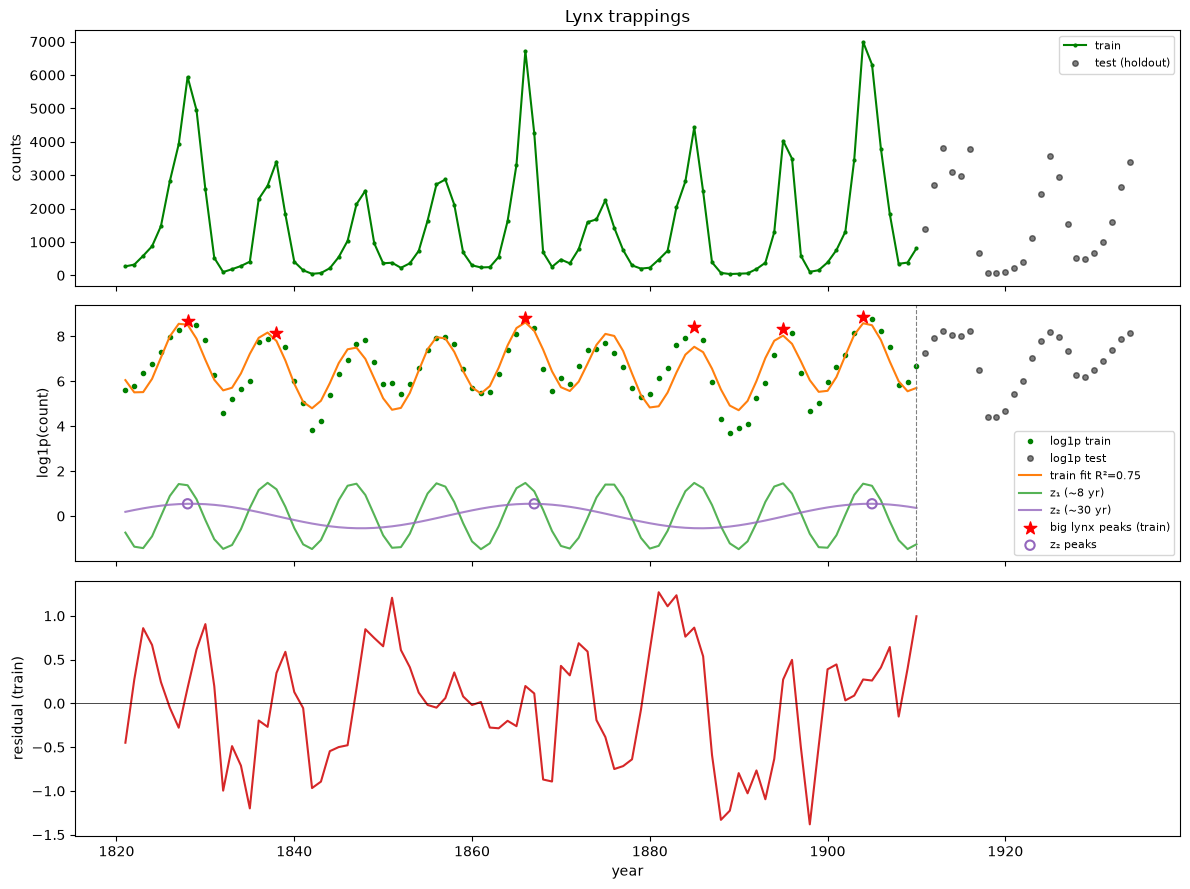

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(years_tr, counts[train_idx], "g.-", ms=4, label="train")
axes[0].plot(years_te, counts[test_idx], "ko", ms=4, alpha=0.5, label="test (holdout)")
axes[0].set_ylabel("counts")
axes[0].set_title("Lynx trappings")
axes[0].legend(fontsize=8)

axes[1].plot(years_tr, y_tr, "g.", label="log1p train")
axes[1].plot(years_te, y_te, "ko", ms=4, alpha=0.5, label="log1p test")
axes[1].plot(years_tr, fit["y_hat_log"], "C1", lw=1.5, label=f"train fit R²={fit['r2_log']:.2f}")
axes[1].plot(years_tr, fit["component1_log"], "C2", alpha=0.8, label=f"z₁ (~{s1['period_years']:.0f} yr)")
axes[1].plot(years_tr, fit["component2_log"], "C4", alpha=0.8, label=f"z₂ (~{s2['period_years']:.0f} yr)")
axes[1].scatter(years_tr[fit["big_peak_idx"]], y_tr[fit["big_peak_idx"]], s=90, c="red", marker="*", zorder=5, label="big lynx peaks (train)")
axes[1].scatter(years_tr[fit["z2_peak_idx"]], fit["component2_log"][fit["z2_peak_idx"]], s=45, facecolors="none", edgecolors="C4", lw=1.5, label="z₂ peaks")
axes[1].set_ylabel("log1p(count)")
axes[1].legend(fontsize=8)
axes[1].axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)

axes[2].plot(years_tr, y_tr - fit["y_hat_log"], "C3")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("residual (train)")
axes[2].set_xlabel("year")

plt.tight_layout()
plt.show()

## Step 2: shared warp — dual likelihood (train only)

Learn knot parameters `B` with the same objective as WarpDifferentiable:

`loss = λ·obj_err − (1−λ)·terror_ll` with **λ = 0.5**

- **obj_err**: Gaussian error NLL of `log1p(lynx)` vs warped readout
- **terror_ll**: RW path log-likelihood on warp offsets `p−i`

Path scale is learned via `σ_t`; observation noise via `σ_y`.

In [4]:
from warp_regression import fit_dual_sine_shared_warp

fit_w = fit_dual_sine_shared_warp(
    y_tr, t_tr, years=years_tr, n_knots=14, epochs=1500, fit_lambda=0.5, sine_fit=fit
)
p = fit_w["warp"]["p"]
w = fit_w["warp"]
print(f"Before warp (train): R²={fit_w['r2_log_unwarped']:.3f}")
print(f"After warp (train):  R²={fit_w['r2_log']:.3f}  RMSE={fit_w['rmse_log']:.4f}")
print(f"Dual LL: obj_err={w['obj_err']:.1f}  obj_time={w['obj_time']:.1f}")
print(f"Learned σ_t={w['sigma_t']:.3f} (path), σ_y={w['sigma_y']:.3f} (fit), max|p-i|={w['max_abs_offset']:.2f}")

Before warp (train): R²=0.754
After warp (train):  R²=0.852  RMSE=0.4941
Dual LL: obj_err=64.2  obj_time=0.4
Learned σ_t=0.120 (path), σ_y=0.494 (fit), max|p-i|=1.45


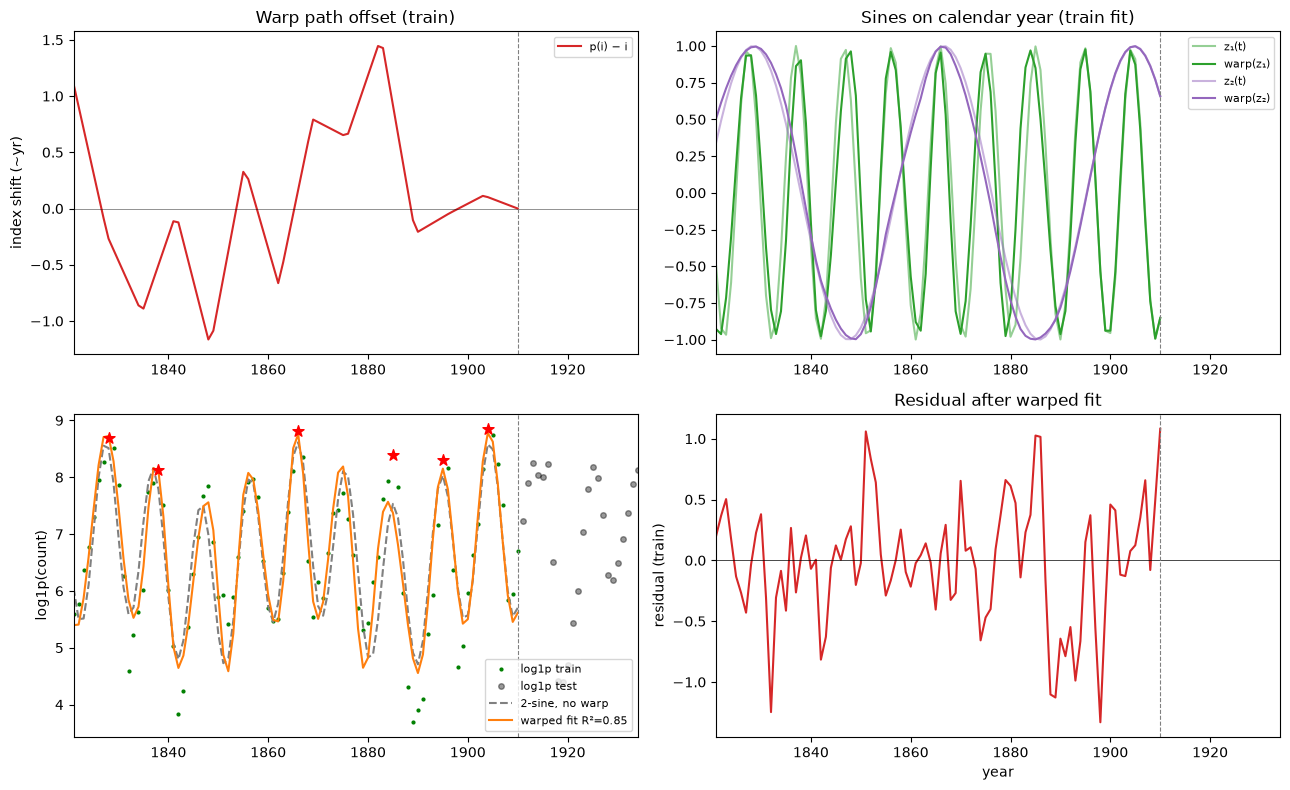

In [5]:
idx_tr = np.arange(n_train)
offset = p - idx_tr

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(years_tr, offset, "C3", lw=1.5, label="p(i) − i")
axes[0, 0].axhline(0, color="k", lw=0.6, alpha=0.5)
axes[0, 0].set_ylabel("index shift (~yr)")
axes[0, 0].set_title("Warp path offset (train)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(years_tr, fit_w["z1"], "C2", alpha=0.5, label="z₁(t)")
axes[0, 1].plot(years_tr, fit_w["z1_warped"], "C2", lw=1.5, label="warp(z₁)")
axes[0, 1].plot(years_tr, fit_w["z2"], "C4", alpha=0.5, label="z₂(t)")
axes[0, 1].plot(years_tr, fit_w["z2_warped"], "C4", lw=1.5, label="warp(z₂)")
axes[0, 1].set_title("Sines on calendar year (train fit)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(years_tr, y_tr, "g.", ms=4, label="log1p train")
axes[1, 0].plot(years_te, y_te, "ko", ms=4, alpha=0.4, label="log1p test")
axes[1, 0].plot(years_tr, fit_w["y_hat_log_unwarped"], "--", color="gray", label="2-sine, no warp")
axes[1, 0].plot(years_tr, fit_w["y_hat_log"], "C1", lw=1.5, label=f"warped fit R²={fit_w['r2_log']:.2f}")
axes[1, 0].scatter(years_tr[fit_w["big_peak_idx"]], y_tr[fit_w["big_peak_idx"]], s=70, c="red", marker="*", zorder=5)
axes[1, 0].set_ylabel("log1p(count)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(years_tr, y_tr - fit_w["y_hat_log"], "C3")
axes[1, 1].axhline(0, color="k", lw=0.5)
axes[1, 1].set_ylabel("residual (train)")
axes[1, 1].set_xlabel("year")
axes[1, 1].set_title("Residual after warped fit")

for ax in axes.ravel():
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])

plt.tight_layout()
plt.show()

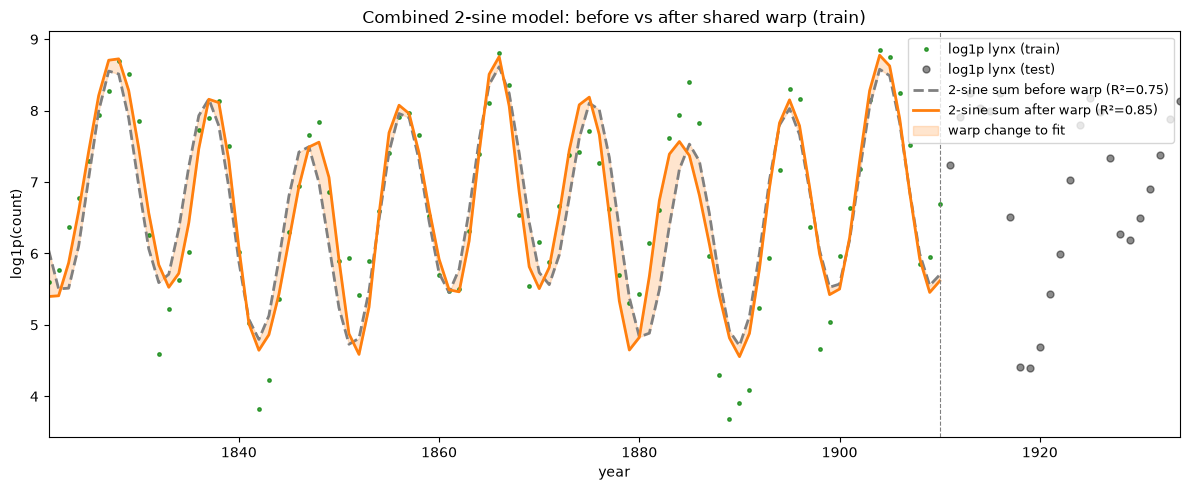

In [6]:
y_before = fit_w["y_hat_log_unwarped"]
y_after = fit_w["y_hat_log"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_tr, y_tr, "g.", ms=5, alpha=0.7, label="log1p lynx (train)")
ax.plot(years_te, y_te, "ko", ms=5, alpha=0.45, label="log1p lynx (test)")
ax.plot(years_tr, y_before, color="gray", ls="--", lw=2, label=f"2-sine sum before warp (R²={fit_w['r2_log_unwarped']:.2f})")
ax.plot(years_tr, y_after, color="C1", ls="-", lw=2, label=f"2-sine sum after warp (R²={fit_w['r2_log']:.2f})")
ax.fill_between(years_tr, y_before, y_after, color="C1", alpha=0.2, label="warp change to fit")
ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
ax.set_xlim(years[0], years[-1])
ax.set_xlabel("year")
ax.set_ylabel("log1p(count)")
ax.set_title("Combined 2-sine model: before vs after shared warp (train)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Step 3: nonlinear readouts f, g (train only)

Same shared warp path on both sines; replace linear coefficients with small MLPs (`hidden=24`, 2 layers — modest capacity to limit error-NLL overfitting):

\[
\widehat{\log(1+\text{lynx})} = f(\mathrm{warp}(z_1)) + g(\mathrm{warp}(z_2))
\]

Trained with **λ = 0.5** (dual loss). Warp knots warm-start from the step‑2 linear warp fit.

In [7]:
from warp_regression import fit_dual_sine_shared_warp_nonlinear

fit_nl = fit_dual_sine_shared_warp_nonlinear(
    y_tr, t_tr, years=years_tr, n_knots=14, epochs=2500, hidden=24, n_hidden_layers=2,
    fit_lambda=0.5, sine_fit=fit,
)
p_nl = fit_nl["warp"]["p"]
print(
    f"unwarped f+g (train): R²={fit_nl['r2_log_unwarped']:.3f}  |  "
    f"linear warp: R²={fit_nl['r2_log_linear_warp']:.3f}  |  "
    f"f(warp)+g(warp): R²={fit_nl['r2_log']:.3f}"
)
print(f"Dual LL: obj_err={fit_nl['warp']['obj_err']:.1f}  obj_time={fit_nl['warp']['obj_time']:.1f}")
print(f"σ_y={fit_nl['warp']['sigma_y']:.3f}  max |p−i| ≈ {fit_nl['warp']['max_abs_offset']:.2f} yr")

unwarped f+g (train): R²=0.754  |  linear warp: R²=0.852  |  f(warp)+g(warp): R²=0.942
Dual LL: obj_err=20.2  obj_time=1.8
σ_y=0.311  max |p−i| ≈ 1.28 yr


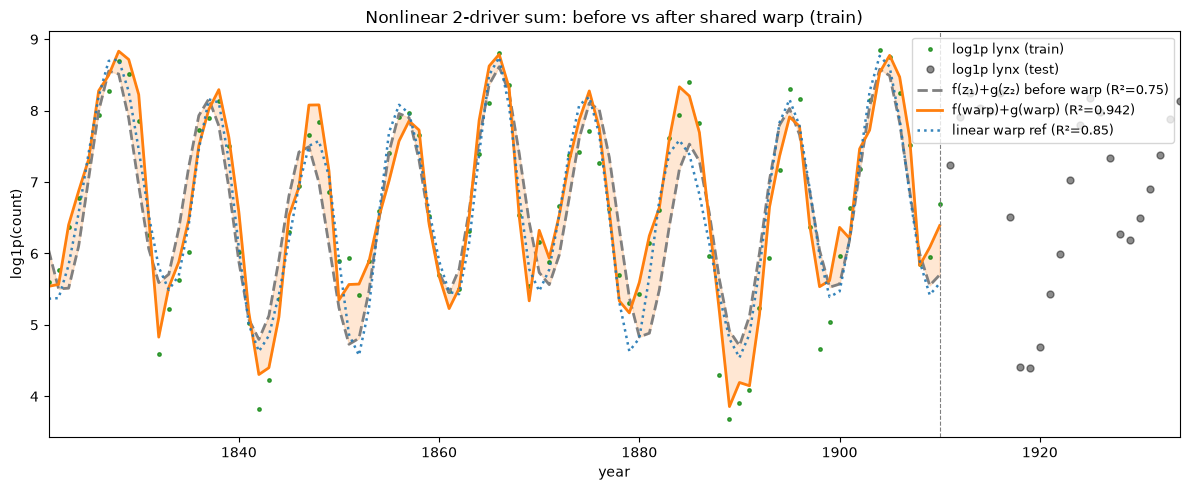

In [8]:
y_nl_before = fit_nl["y_hat_log_unwarped"]
y_nl_after = fit_nl["y_hat_log"]
y_lin_after = fit_nl["y_hat_log_linear_warp"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_tr, y_tr, "g.", ms=5, alpha=0.7, label="log1p lynx (train)")
ax.plot(years_te, y_te, "ko", ms=5, alpha=0.45, label="log1p lynx (test)")
ax.plot(years_tr, y_nl_before, color="gray", ls="--", lw=2, label=f"f(z₁)+g(z₂) before warp (R²={fit_nl['r2_log_unwarped']:.2f})")
ax.plot(years_tr, y_nl_after, color="C1", ls="-", lw=2, label=f"f(warp)+g(warp) (R²={fit_nl['r2_log']:.3f})")
ax.plot(years_tr, y_lin_after, color="C0", ls=":", lw=1.8, alpha=0.9, label=f"linear warp ref (R²={fit_nl['r2_log_linear_warp']:.2f})")
ax.fill_between(years_tr, y_nl_before, y_nl_after, color="C1", alpha=0.18)
ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
ax.set_xlim(years[0], years[-1])
ax.set_xlabel("year")
ax.set_ylabel("log1p(count)")
ax.set_title("Nonlinear 2-driver sum: before vs after shared warp (train)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

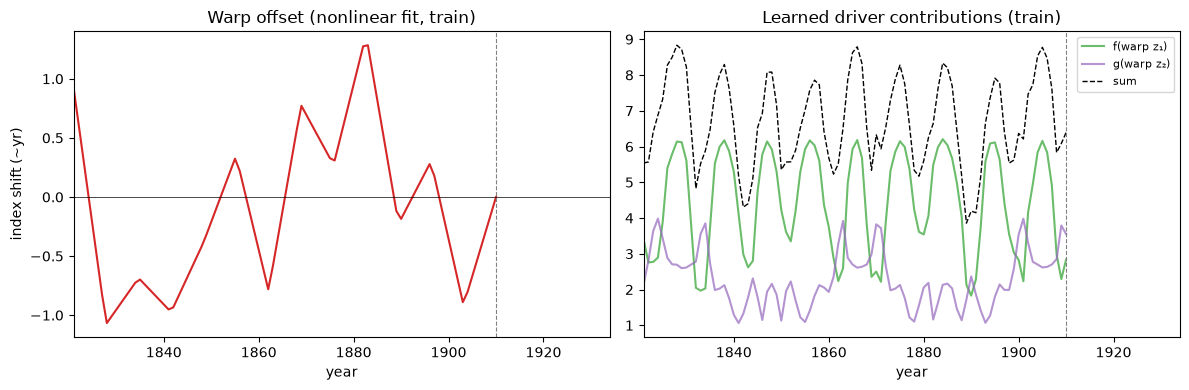

In [9]:
offset_nl = p_nl - np.arange(n_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(years_tr, offset_nl, "C3", lw=1.5)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("index shift (~yr)")
axes[0].set_title("Warp offset (nonlinear fit, train)")
axes[1].plot(years_tr, fit_nl["component1_log"], "C2", alpha=0.7, label="f(warp z₁)")
axes[1].plot(years_tr, fit_nl["component2_log"], "C4", alpha=0.7, label="g(warp z₂)")
axes[1].plot(years_tr, fit_nl["y_hat_log"], "k--", lw=1, label="sum")
axes[1].set_title("Learned driver contributions (train)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])
    ax.set_xlabel("year")
plt.tight_layout()
plt.show()

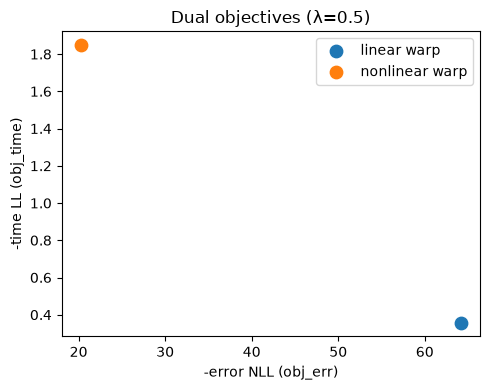

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter([fit_w['warp']['obj_err']], [fit_w['warp']['obj_time']], s=80, label='linear warp')
ax.scatter([fit_nl['warp']['obj_err']], [fit_nl['warp']['obj_time']], s=80, label='nonlinear warp')
ax.set_xlabel('-error NLL (obj_err)')
ax.set_ylabel('-time LL (obj_time)')
ax.set_title('Dual objectives (λ=0.5)')
ax.legend()
plt.tight_layout()
plt.show()


## Step 4: holdout forecast — terror + error + combined 95% bands

Forecast the test period using the step‑3 train fit (no refit on test).

- **Drivers:** fixed `(ω, φ)` sines extrapolated on the full calendar axis.
- **Warp paths:** train offsets fixed; future offsets follow RW with `σ_index = σ_t·√rw`.
- **Uncertainty:** terror (path RW), error (`±1.96σ_y` around point forecast), combined (`paths_terror + N(0,σ_y)`), all at **95%** on the holdout.

In [11]:
from warp_regression import build_dual_sines_from_fit, forecast_lynx_holdout_paths, per_index_rw_sigma

z1, z2 = build_dual_sines_from_fit(t, fit)
fit_nl["_y_log_train"] = y_tr
fit_nl["_y_log_test"] = y_te
fit_nl["warp"]["n_knots"] = 14

fc = forecast_lynx_holdout_paths(fit_nl, z1, z2, split, n_paths=500, seed=43)
bands = fc["bands"]
n_knots = fit_nl["warp"].get("n_knots", 14)

print(f"Train years {years_tr[0]}–{years_tr[-1]} (n={n_train})")
print(f"Test years  {years_te[0]}–{years_te[-1]} (n={split['n_test']})")
print(f"In-sample fit R² (train, point path) = {fit_nl['r2_log']:.3f}")
print(f"Point forecast train/test corr = {fc['corr_log_train']:.3f} / {fc['corr_log_test']:.3f}")
print(f"Test RMSE (log, point) = {fc['rmse_log_test']:.3f}")
print(f"σ_t={fc['sigma_t']:.3f}  σ_y={fc['sigma_y']:.3f}  σ_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f}")
print(f"Test in combined 95% band: {fc['coverage_combined_95_test']*100:.0f}%")

Train years 1821–1910 (n=90)
Test years  1911–1934 (n=24)
In-sample fit R² (train, point path) = 0.942
Point forecast train/test corr = 0.974 / 0.758
Test RMSE (log, point) = 1.244
σ_t=0.163  σ_y=0.311  σ_index=0.427
Test in combined 95% band: 100%


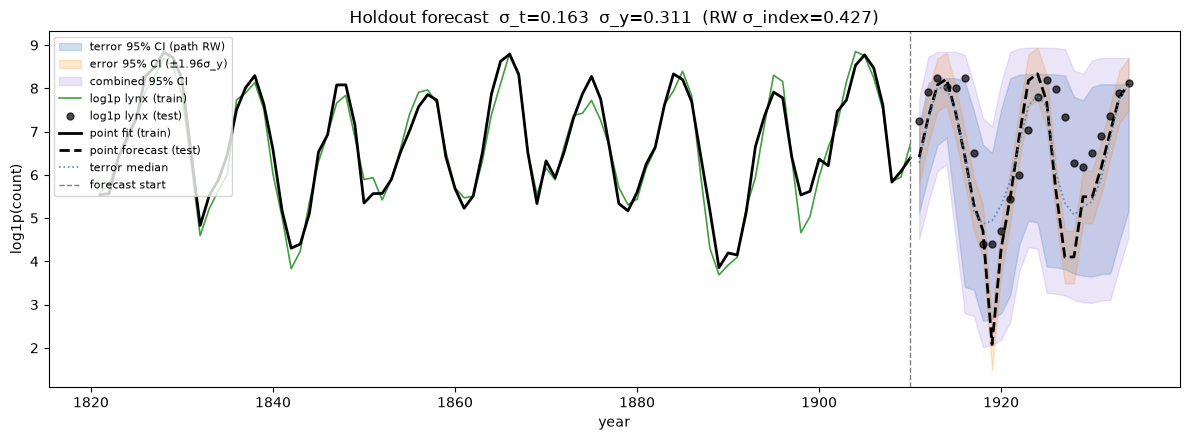

terror  band width at test start/end: 2.0206 / 2.9228
error   band width at test start/end: 1.2179 / 1.2179
combined band width at test start/end: 3.2384 / 4.1407


In [12]:
train_end = split["train_end_year"]
y_point = fc["y_point"]
sigma_y = fc["sigma_y"]
t_q_lo, t_q50, t_q_hi = bands["t_q_lo"], bands["t_q50"], bands["t_q_hi"]
err_lo, err_hi = bands["err_lo"], bands["err_hi"]
c_q_lo, c_q_hi = bands["c_q_lo"], bands["c_q_hi"]
yt = years[test_idx]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(yt, t_q_lo[test_idx], t_q_hi[test_idx], color="steelblue", alpha=0.25, label="terror 95% CI (path RW)")
ax.fill_between(yt, err_lo[test_idx], err_hi[test_idx], color="darkorange", alpha=0.2, label="error 95% CI (±1.96σ_y)")
ax.fill_between(yt, c_q_lo[test_idx], c_q_hi[test_idx], color="mediumpurple", alpha=0.18, label="combined 95% CI")
ax.plot(years_tr, y_tr, color="green", linewidth=1.2, alpha=0.75, label="log1p lynx (train)")
ax.plot(yt, y_te, "ko", ms=5, alpha=0.7, label="log1p lynx (test)")
ax.plot(years_tr, y_point[train_idx], color="black", linewidth=2, label="point fit (train)")
ax.plot(yt, y_point[test_idx], color="black", linewidth=2, linestyle="--", label="point forecast (test)")
ax.plot(yt, t_q50[test_idx], color="steelblue", linewidth=1.2, linestyle=":", alpha=0.9, label="terror median")
ax.axvline(train_end, color="gray", linestyle="--", linewidth=1, label="forecast start")
ax.set_xlabel("year")
ax.set_ylabel("log1p(count)")
ax.set_title(
    f"Holdout forecast  σ_t={fc['sigma_t']:.3f}  σ_y={sigma_y:.3f}  "
    f"(RW σ_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f})"
)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

f0, f1 = test_idx[0], test_idx[-1]
print(f"terror  band width at test start/end: {(t_q_hi[f0]-t_q_lo[f0]):.4f} / {(t_q_hi[f1]-t_q_lo[f1]):.4f}")
print(f"error   band width at test start/end: {(err_hi[f0]-err_lo[f0]):.4f} / {(err_hi[f1]-err_lo[f1]):.4f}")
print(f"combined band width at test start/end: {(c_q_hi[f0]-c_q_lo[f0]):.4f} / {(c_q_hi[f1]-c_q_lo[f1]):.4f}")

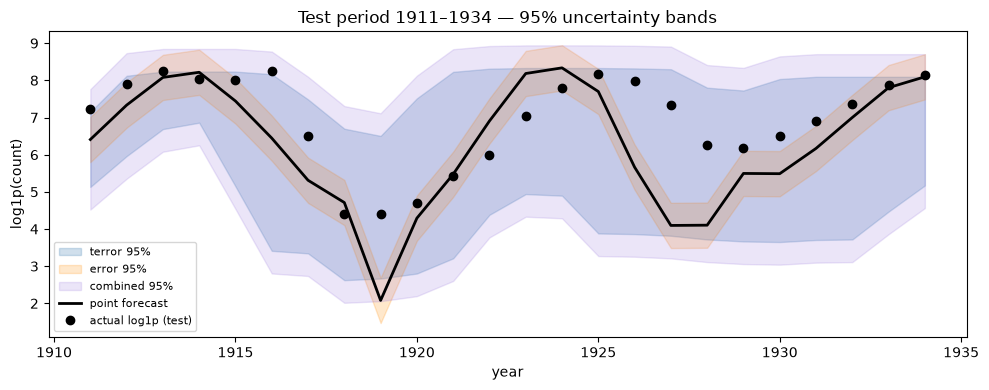

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(yt, t_q_lo[test_idx], t_q_hi[test_idx], color="steelblue", alpha=0.25, label="terror 95%")
ax.fill_between(yt, err_lo[test_idx], err_hi[test_idx], color="darkorange", alpha=0.2, label="error 95%")
ax.fill_between(yt, c_q_lo[test_idx], c_q_hi[test_idx], color="mediumpurple", alpha=0.18, label="combined 95%")
ax.plot(yt, y_point[test_idx], "k-", lw=2, label="point forecast")
ax.plot(yt, y_te, "ko", ms=6, label="actual log1p (test)")
ax.set_title(f"Test period {yt[0]}–{yt[-1]} — 95% uncertainty bands")
ax.set_xlabel("year")
ax.set_ylabel("log1p(count)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

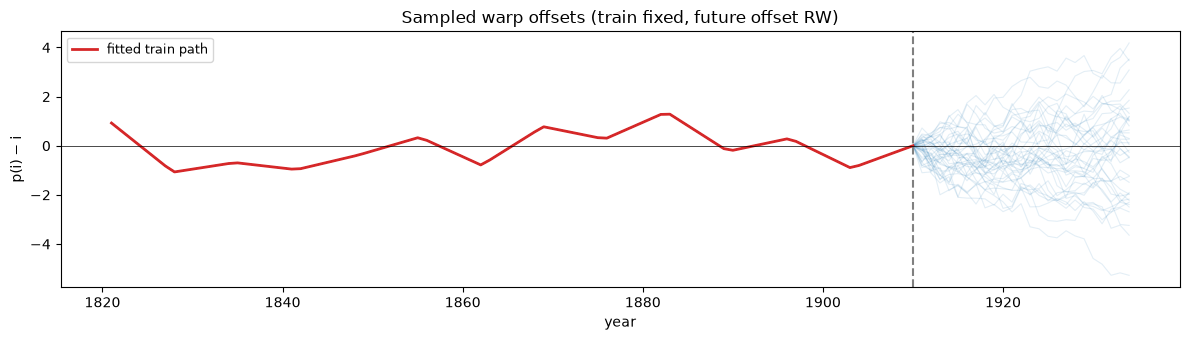

In [14]:
# Example future warp paths (offset from identity)
paths_p = fc["paths_p"]
idx = np.arange(len(years))
fig, ax = plt.subplots(figsize=(12, 3.5))
for k in range(min(40, len(paths_p))):
    ax.plot(years, paths_p[k] - idx, color="C0", alpha=0.12, lw=0.8)
ax.plot(years_tr, fit_nl["warp"]["p"] - idx[:n_train], "C3", lw=2, label="fitted train path")
ax.axvline(train_end, color="gray", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("p(i) − i")
ax.set_xlabel("year")
ax.set_title("Sampled warp offsets (train fixed, future offset RW)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Step 5: original scale (counts)

Map log1p predictions and bands back with `expm1`. Band bounds are transformed pointwise (approximate on the count scale).


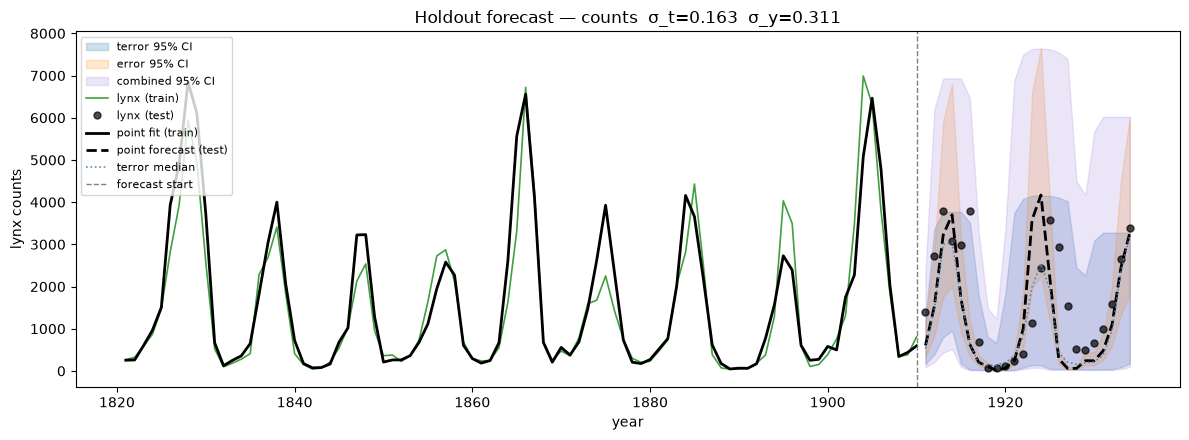

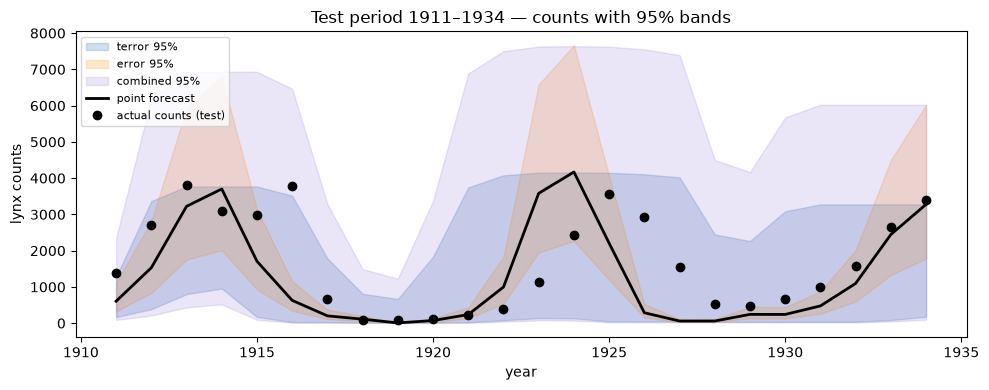

Test in combined 95% band (counts): 100%
Test RMSE (counts, point): 1226


In [15]:
def to_counts(z_log):
    return np.maximum(np.expm1(z_log), 0.0)

counts_tr = counts[train_idx]
counts_te = counts[test_idx]
y_hat_tr = to_counts(y_point[train_idx])
y_hat_te = to_counts(y_point[test_idx])

t_lo_c, t_hi_c = to_counts(t_q_lo[test_idx]), to_counts(t_q_hi[test_idx])
err_lo_c, err_hi_c = to_counts(err_lo[test_idx]), to_counts(err_hi[test_idx])
c_lo_c, c_hi_c = to_counts(c_q_lo[test_idx]), to_counts(c_q_hi[test_idx])
t_med_c = to_counts(t_q50[test_idx])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(yt, t_lo_c, t_hi_c, color="steelblue", alpha=0.25, label="terror 95% CI")
ax.fill_between(yt, err_lo_c, err_hi_c, color="darkorange", alpha=0.2, label="error 95% CI")
ax.fill_between(yt, c_lo_c, c_hi_c, color="mediumpurple", alpha=0.18, label="combined 95% CI")
ax.plot(years_tr, counts_tr, color="green", linewidth=1.2, alpha=0.75, label="lynx (train)")
ax.plot(yt, counts_te, "ko", ms=5, alpha=0.7, label="lynx (test)")
ax.plot(years_tr, y_hat_tr, color="black", linewidth=2, label="point fit (train)")
ax.plot(yt, y_hat_te, color="black", linewidth=2, linestyle="--", label="point forecast (test)")
ax.plot(yt, t_med_c, color="steelblue", linewidth=1.2, linestyle=":", alpha=0.9, label="terror median")
ax.axvline(train_end, color="gray", linestyle="--", linewidth=1, label="forecast start")
ax.set_xlabel("year")
ax.set_ylabel("lynx counts")
ax.set_title(f"Holdout forecast — counts  σ_t={fc['sigma_t']:.3f}  σ_y={sigma_y:.3f}")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(yt, t_lo_c, t_hi_c, color="steelblue", alpha=0.25, label="terror 95%")
ax.fill_between(yt, err_lo_c, err_hi_c, color="darkorange", alpha=0.2, label="error 95%")
ax.fill_between(yt, c_lo_c, c_hi_c, color="mediumpurple", alpha=0.18, label="combined 95%")
ax.plot(yt, y_hat_te, "k-", lw=2, label="point forecast")
ax.plot(yt, counts_te, "ko", ms=6, label="actual counts (test)")
ax.set_title(f"Test period {yt[0]}–{yt[-1]} — counts with 95% bands")
ax.set_xlabel("year")
ax.set_ylabel("lynx counts")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

in_combined = (counts_te >= c_lo_c) & (counts_te <= c_hi_c)
print(f"Test in combined 95% band (counts): {in_combined.mean()*100:.0f}%")
print(f"Test RMSE (counts, point): {np.sqrt(np.mean((y_hat_te - counts_te)**2)):.0f}")
